## Loading Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/fmnist_small.csv')

In [3]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [4]:
X = df.drop('label', axis=1)
y = df['label']

## view data as image

In [5]:
from matplotlib import pyplot as plt
import numpy as np

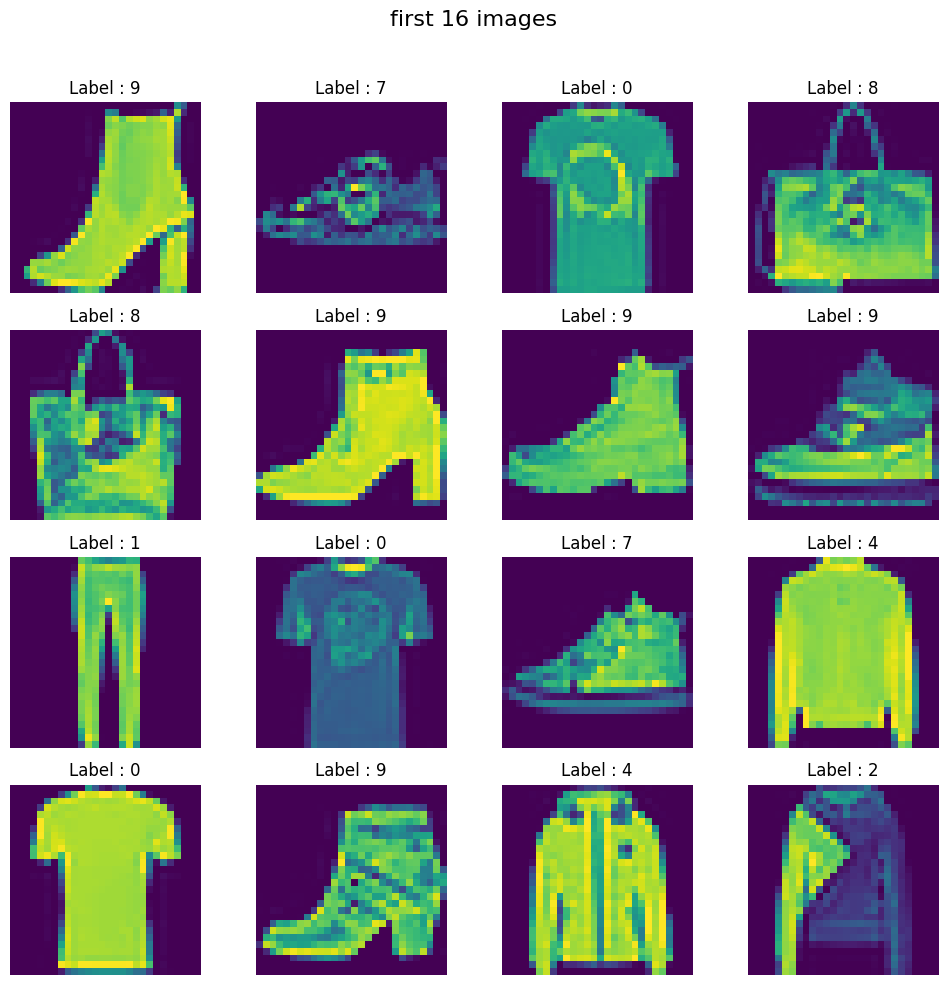

In [6]:
fig , axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("first 16 images",fontsize = 16)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label : {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## Data splitting

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
#scalling the data

X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
X_train=X_train.values
X_test=X_test.values
y_train=y_train.values
y_test=y_test.values


## create custom dataset

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

In [11]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]


In [12]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [13]:
train_dataloader = DataLoader(train_dataset,batch_size=64,shuffle=True,pin_memory=True)
test_dataloader = DataLoader(test_dataset,batch_size=64,shuffle=False,pin_memory=True)

## Create A Model

In [14]:
import torch.nn as nn

In [15]:
class Network(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model = nn.Sequential(
    nn.Linear(num_features,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,10),
    )

  def forward(self,x):
    return self.model(x)




## define parameters

In [16]:
epochs = 1000
learning_rate = 0.01


In [17]:
print(torch.cuda.is_available())

True


In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
device

device(type='cuda')

In [20]:
# instatiate the model
model = Network(X_train.shape[1])

#move device to gpu
model = model.to(device)

#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

In [ ]:
# training loop

for epoch in range(epochs):
  total_epoch_loss = 0
  for i, (features,labels) in enumerate(train_dataloader):
    # Print device for a few batches to verify
    if i == 0 and epoch == 0: # Only print for the first batch of the first epoch
      print(f"Initial Features device: {features.device}")
      print(f"Initial Labels device: {labels.device}")
      print(f"Model parameters device: {next(model.parameters()).device}")

    #forward
    features = features.to(device)
    labels = labels.to(device)
    y_pred = model(features)

    #loss calculation
    loss = criterion(y_pred,labels)

    #backward
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()
    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_dataloader)
  print(f"epoch : {epoch} loss : {avg_loss}")

Initial Features device: cpu
Initial Labels device: cpu
Model parameters device: cuda:0
epoch : 0 loss : 0.9406440072890484
epoch : 1 loss : 0.5906858046849569
epoch : 2 loss : 0.5079730690428705
epoch : 3 loss : 0.45889105625224835
epoch : 4 loss : 0.4037290391596881
epoch : 5 loss : 0.39140302258910553
epoch : 6 loss : 0.39732981450629956
epoch : 7 loss : 0.35972810356002866
epoch : 8 loss : 0.3382808500618646
epoch : 9 loss : 0.3531608407696088
epoch : 10 loss : 0.2999611934929183
epoch : 11 loss : 0.2960009981285442
epoch : 12 loss : 0.2574381561893405
epoch : 13 loss : 0.2926744312951059
epoch : 14 loss : 0.2667417703478625
epoch : 15 loss : 0.25262655453248456
epoch : 16 loss : 0.29190955277193675
epoch : 17 loss : 0.2456589133450479
epoch : 18 loss : 0.25157663598656654
epoch : 19 loss : 0.24296887704368794
epoch : 20 loss : 0.2615494134299683
epoch : 21 loss : 0.22220305223582368
epoch : 22 loss : 0.22589046316164912
epoch : 23 loss : 0.21613483430083955
epoch : 24 loss : 0.193

In [ ]:
#set model to eval mode
total = 0
correct = 0
model.eval()

with torch.no_grad():
  for feature,label in test_dataloader:

    feature = feature.to(device)
    label = label.to(device)

    y_pred = model(feature)
    _,prediction= torch.max(y_pred,1)
    total = total + label.shape[0]
    correct = correct + (prediction == label).sum().item()
print(correct / total)


